# 3. Centerline extraction with VMTK

From a binary vessel mask to a set of centerlines with radii. The stage runs entirely on the CPU with VTK and VMTK: it builds a surface, finds the ends of every vessel, traces the centerlines, splits them into branches and finally flattens everything into one array that the later stages read.

This uses the fixture segmentation and takes under a minute in fast mode.


Arterial framework for automated characterization of vascular tortuosity.
Copyright 2022-2026 Vall d'Hebron Research Institute (VHIR) and Universitat de Barcelona (UB), Barcelona, Spain.
Code licensed under the PolyForm Noncommercial License 1.0.0. Noncommercial use only.



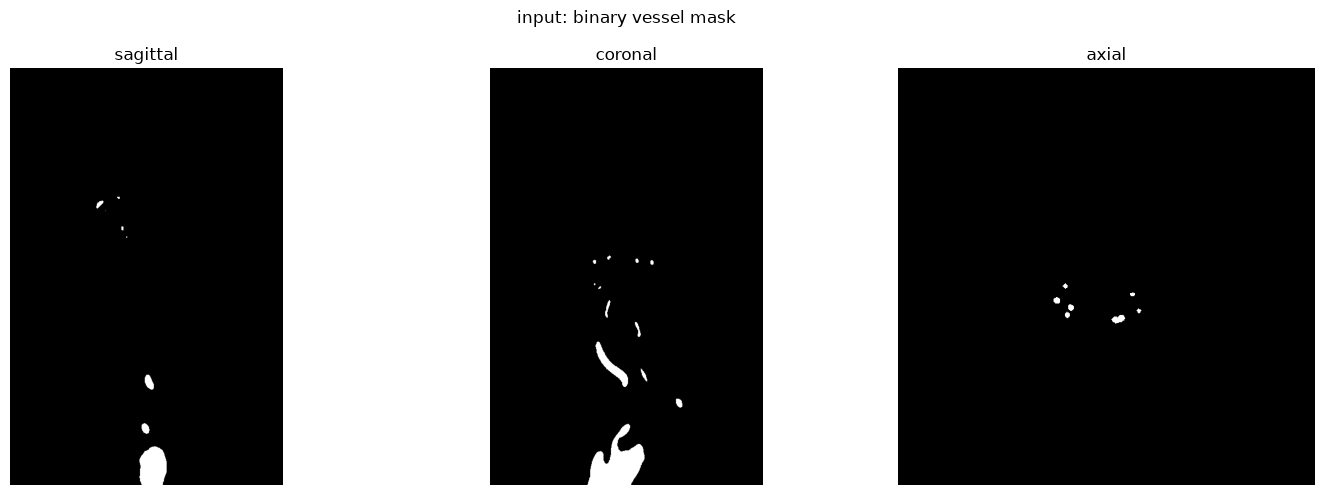

In [1]:
import numpy as np, nibabel as nib, matplotlib.pyplot as plt
from arterial_nb import *
from arterial.io.load_and_save_operations import load_json, load_vtkpolydata
from arterial.centerline_extraction.centerline_extractor import CenterlineExtractor
from arterial.centerline_extraction.preprocessing.utils import split_segmentation

segmentation = nib.load(fixture("segmentation.nii.gz"))
seg_array = np.asarray(segmentation.dataobj)
extractor = CenterlineExtractor(case("centerlines"), MODE, fixture("segmentation.nii.gz"), fast_segmentation=True)
show_slices(seg_array, window=(0, 1), title="input: binary vessel mask");

## Islands

A segmentation is rarely one connected piece. Each connected island is processed separately; tiny ones are dropped. Fast mode also removes the top ten percent of the volume, where the intracranial tree would make endpoint detection slow and fragile.

In [2]:
islands = split_segmentation(seg_array, segmentation.affine, minimum_island_voxel_size=1000)
voxel_mm3 = float(np.prod(np.abs(np.diag(segmentation.affine)[:3])))
table([[i, int(island.sum()), round(island.sum() * voxel_mm3 / 1000, 1)] for i, island in enumerate(islands)], columns=["island", "voxels", "cm3"])

,island,voxels,cm3
0,0,838292,98.9
1,1,9225,1.1
2,2,8133,1.0
3,3,2075,0.2
4,4,1410,0.2
5,5,1358,0.2
6,6,1045,0.1
7,7,670,0.1


## Surface

Marching cubes turns each island into a triangle mesh, which is smoothed and decimated. VMTK works on this surface, not on the voxels.

preprocessing: 16.0 s
38542 points, 77096 triangles, 3 island surfaces


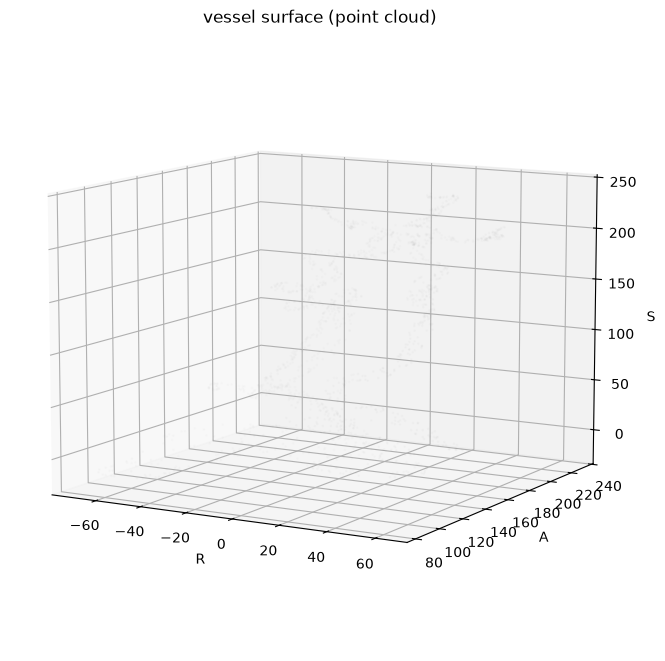

In [3]:
with timed("preprocessing"), quiet():
    extractor.perform_preprocessing()
surface = extractor.segmentation_model
print(f"{surface.GetNumberOfPoints()} points, {surface.GetNumberOfCells()} triangles, {len(extractor.segmentation_model_list)} island surfaces")
plot_polydata([surface], colors=["gray"], title="vessel surface (point cloud)");

## Endpoints and centerlines

For every island surface VMTK first extracts a coarse network to detect the free ends of the vessels. One end near the aortic arch is chosen as the start; the centerlines are then traced from it to every other endpoint as the path of maximal inscribed spheres. The sphere radius at each point becomes the vessel radius.

In [4]:
with timed("centerline extraction"), quiet():
    extractor.perform_centerline_extraction()
import glob, json
rows = []
for idx, model in enumerate(extractor.centerline_model_list):
    endpoints = load_json(os.path.join(extractor.endpoints_dir_path, f"endpoints_{idx}.json"))["markups"][0]["controlPoints"]
    rows.append([idx, len(endpoints), model.GetNumberOfCells(), model.GetNumberOfPoints()])
table(rows, columns=["island", "endpoints", "centerline cells", "points"])

2026-09-11 17:21:30.186 (  26.052s) [        D23F8740]vtkvmtkPolyDataNetworkE:593    ERR| vtkvmtkPolyDataNetworkExtraction (0x63ff03d56e40): Error: can't reconstruct new profile.


2026-09-11 17:21:32.975 (  28.841s) [        D23F8740]vtkvmtkPolyDataNetworkE:593    ERR| vtkvmtkPolyDataNetworkExtraction (0x63ff08dedd30): Error: can't reconstruct new profile.
2026-09-11 17:21:33.383 (  29.249s) [        D23F8740]vtkvmtkSteepestDescentL:213   WARN| vtkvmtkSteepestDescentLineTracer (0x63ff08de46e0): Can't find a steepest descent edge. Target not reached.


centerline extraction: 3.7 s


2026-09-11 17:21:33.849 (  29.715s) [        D23F8740]vtkvmtkSteepestDescentL:213   WARN| vtkvmtkSteepestDescentLineTracer (0x63ff08de46e0): Can't find a steepest descent edge. Target not reached.


,island,endpoints,centerline cells,points
0,0,12,11,2627
1,1,7,5,497
2,2,5,3,489


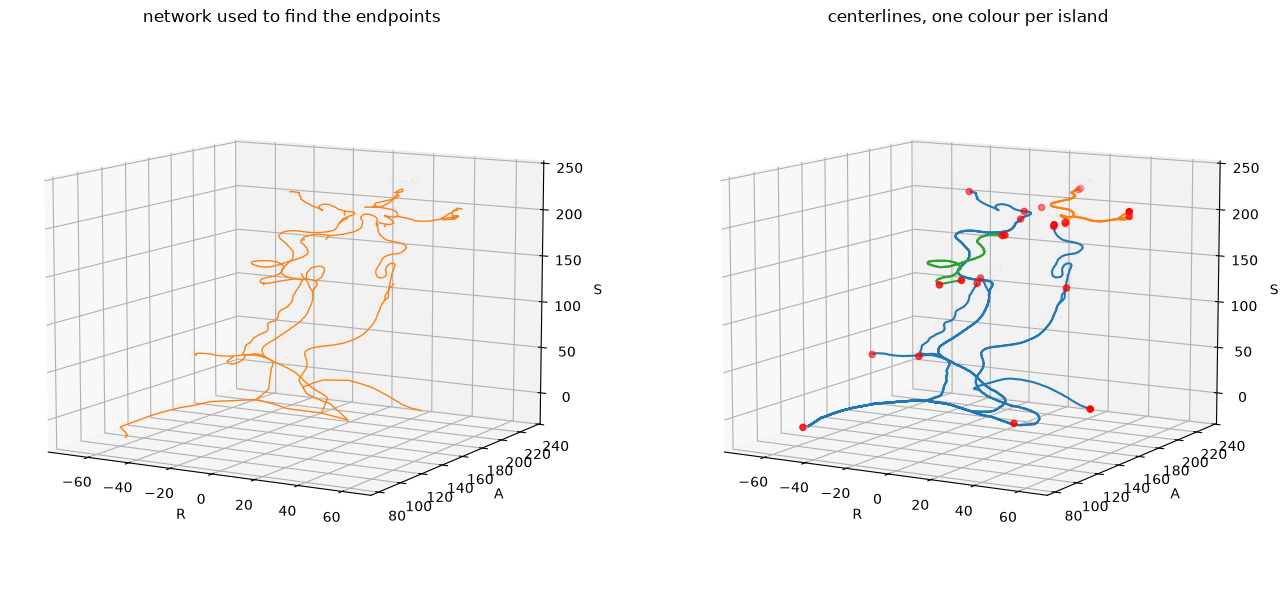

In [5]:
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(121, projection="3d")
plot_polydata([surface] + extractor.network_list, colors=["lightgray"] + ["C1"] * len(extractor.network_list), ax=ax, title="network used to find the endpoints")
ax = fig.add_subplot(122, projection="3d")
plot_polydata([surface] + extractor.centerline_model_list, colors=["lightgray"] + [f"C{i}" for i in range(len(extractor.centerline_model_list))], ax=ax, title="centerlines, one colour per island", linewidth=1.5)
for idx in range(len(extractor.centerline_model_list)):
    pts = np.array([p["position"] for p in load_json(os.path.join(extractor.endpoints_dir_path, f"endpoints_{idx}.json"))["markups"][0]["controlPoints"]])
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], color="red", s=20)

## Branches

The centerlines overlap where several paths share a trunk. The branch extractor splits them at bifurcations into non-overlapping branches and flags the points close to a bifurcation as *blanked*: radii there are unreliable because the inscribed sphere touches two vessels.

branch extraction: 3.2 s
119 branches, 50 of them blanked (near a bifurcation)


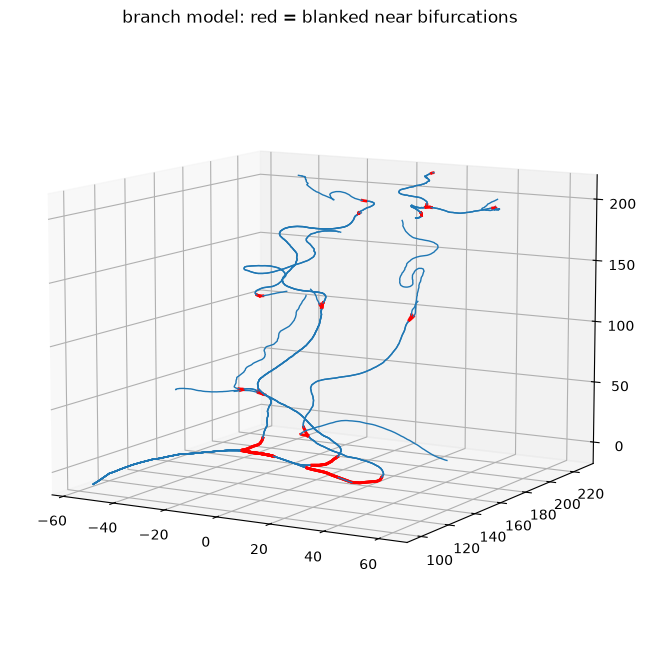

In [6]:
with timed("branch extraction"), quiet():
    extractor.perform_branch_model_extraction()
from vtk.util.numpy_support import vtk_to_numpy
branch = extractor.branch_model
blanking = vtk_to_numpy(branch.GetCellData().GetArray("Blanking"))
print(f"{branch.GetNumberOfCells()} branches, {int(blanking.sum())} of them blanked (near a bifurcation)")
lines = polydata_lines(branch)
fig = plt.figure(figsize=(8, 9)); ax = fig.add_subplot(111, projection="3d")
for line, flag in zip(lines, blanking):
    ax.plot(line[:, 0], line[:, 1], line[:, 2], color="red" if flag else "C0", linewidth=2 if flag else 1)
ax.set_title("branch model: red = blanked near bifurcations"); ax.view_init(10, -60);

## The segments array

The last step flattens the branches into a plain numpy array: one row per segment holding its ordered coordinates and radii, in RAS millimetres. Duplicated points and closed loops are removed, and in extracranial mode the small vessels at the very top are dropped. This array is what vessel labelling and feature extraction read.

In [7]:
with timed("postprocessing"), quiet():
    extractor.perform_centerline_postprocessing()
segments = extractor.centerline_segments_array
lengths = [np.linalg.norm(np.diff(c, axis=0), axis=1).sum() for c in segments[:, 0]]
radii = [r.mean() for r in segments[:, 1]]
table([[i, len(c), round(l, 1), round(r, 2)] for i, (c, l, r) in enumerate(zip(segments[:, 0], lengths, radii))][:12],
      columns=["segment", "points", "length (mm)", "mean radius (mm)"])

postprocessing: 0.2 s


,segment,points,length (mm),mean radius (mm)
0,0,41,53.6,13.04
1,1,72,52.2,6.67
2,2,114,49.5,2.79
3,3,29,11.1,1.79
4,4,17,5.1,1.29
5,5,348,91.9,1.25
6,6,24,28.2,11.80
7,7,322,157.3,3.34
8,8,76,20.0,1.90
9,9,9,15.5,12.42


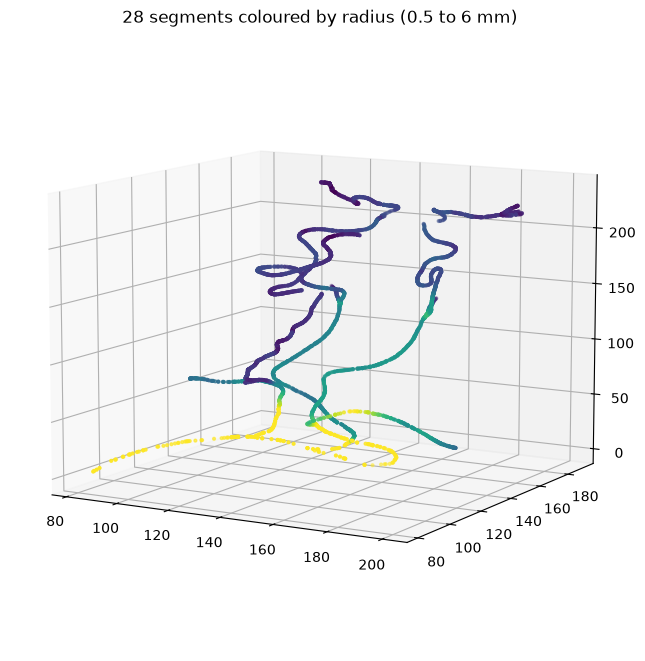

In [8]:
fig = plt.figure(figsize=(8, 9)); ax = fig.add_subplot(111, projection="3d")
for coords, r in zip(segments[:, 0], segments[:, 1]):
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=r, cmap="viridis", s=4, vmin=0.5, vmax=6)
ax.set_title(f"{len(segments)} segments coloured by radius (0.5 to 6 mm)"); ax.view_init(10, -60);

## Notes

- VMTK prints `can't reconstruct new profile` for some islands; that is a warning from the network extraction and the island still gets its centerlines.
- Branch extraction runs in a separate process because a VMTK crash there would otherwise take the whole pipeline down. If it fails for the first (largest) island the stage stops; smaller islands are skipped.
- Full mode keeps the intracranial vessels and takes much longer on the same case.